# 05. 뉴스 신호 진단

처음 계획은 매일 커피 뉴스를 모아 TypeSafe Jev로 상승·하락 압력 확률을 매기고, 그 점수를 예측에 넣는 것이었다. 이 노트북은 뉴스 점수를 모델 입력으로 써도 되는지 **진단**한다.

먼저 밝혀 둘 사실이 있다. 2022–2025년 기사는 2026년 9월에 한꺼번에 소급 분류했다. 그 날짜에 실제로 쓸 수 있었던 점수가 아니다. 그래서 연구용으로는 "발행 다음 날 알았다"고 가정한다(`daily_news(mode="research")`). 이 가정에는 위험이 두 가지 있다.

1. 분석 모델이 2026년의 지식으로 이후 가격 움직임을 이미 알고 있을 수 있다.
2. 기사 자체가 이미 일어난 움직임을 설명하는 글일 수 있다(사후 설명).

질문은 세 가지다.

1. 연도별 기사 수와 라벨 분포가 안정적인가?
2. 점수가 미래 수익률보다 과거 수익률과 더 관련되는가? (사후 설명 점검)
3. 미리 정한 실험 1개: 5거래일 수익률 예측(기준 = 현재가 유지)에 뉴스 점수를 계수 하나로 더하면 오차가 줄어드는가?

**채택 규칙(결과를 보기 전에 고정):** 2023–2025 walk-forward에서 블록 bootstrap ΔRMSE의 95% 구간이 0보다 작고, 세 해 모두 오차가 줄어야 채택한다.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import common
from coffee.evaluate import block_bootstrap_rmse_diff
from coffee.features import build_dataset
from coffee.news import daily_news, load_jev_archive
from coffee.sources import load_sources

data = build_dataset(load_sources())
articles = load_jev_archive()
news = daily_news(articles, data.index, mode="research")
print(f"기사 {len(articles):,}건, {articles['event_at'].min():%Y-%m-%d} ~ {articles['event_at'].max():%Y-%m-%d}")

기사 1,446건, 2022-01-04 ~ 2026-09-25


## 1. 수집 범위와 라벨 분포

뉴스 점수는 거래일마다 `tanh(Σ (P상승 − P하락) × 관련성)`이다. 기사가 없는 날은 결측이다.

In [2]:
LABELS = {"bullish": "상승 압력", "bearish": "하락 압력", "neutral": "중립", "uncertain": "불확실"}
articles["연도"] = articles["event_at"].dt.year
articles["분석 지연(일)"] = (articles["analyzed_at"] - articles["event_at"]).dt.total_seconds() / 86400

share = pd.crosstab(articles["연도"], articles["label"], normalize="index")[list(LABELS)].rename(columns=LABELS)
covered = news.loc["2022":, "news_count"].gt(0)
summary = pd.DataFrame({
    "기사 수": articles.groupby("연도").size(),
    "기사 있는 거래일 비율": covered.groupby(covered.index.year).mean(),
    "분석 지연 중앙값(일)": articles.groupby("연도")["분석 지연(일)"].median(),
})
pd.concat([summary, share], axis=1).round(2)

,기사 수,기사 있는 거래일 비율,분석 지연 중앙값(일),상승 압력,하락 압력,중립,불확실
2022,189,0.66,1545.32,0.16,0.05,0.06,0.73
2023,213,0.75,1173.31,0.12,0.07,0.09,0.73
2024,256,0.87,803.80,0.19,0.09,0.06,0.66
2025,382,0.96,404.79,0.22,0.13,0.05,0.61
2026,406,0.96,129.52,0.30,0.23,0.05,0.42


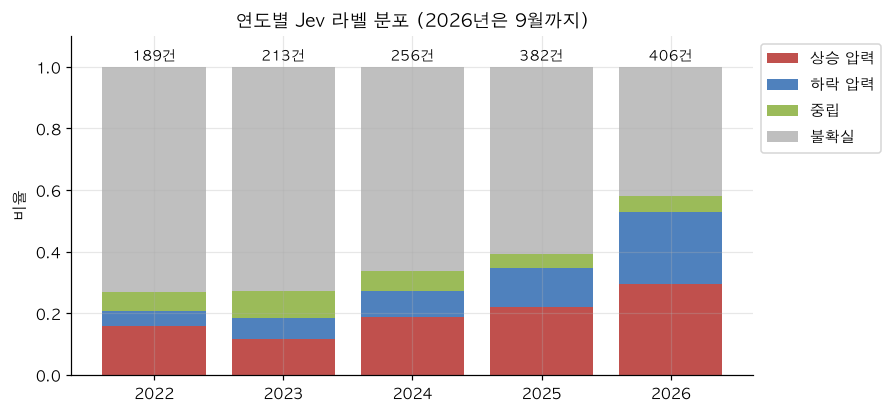

In [3]:
colors = {"상승 압력": "#c0504d", "하락 압력": "#4f81bd", "중립": "#9bbb59", "불확실": "#bfbfbf"}
fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(len(share))
for name in share.columns:
    ax.bar(share.index.astype(str), share[name], bottom=bottom, color=colors[name], label=name)
    bottom += share[name].to_numpy()
for x, n in zip(share.index.astype(str), summary["기사 수"]):
    ax.text(x, 1.02, f"{n}건", ha="center", fontsize=9)
ax.set(ylim=(0, 1.1), ylabel="비율", title="연도별 Jev 라벨 분포 (2026년은 9월까지)")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
common.save_fig(fig, "news_labels_by_year.png")
plt.show()

수집량과 라벨 분포가 해마다 크게 바뀌었다. 기사가 있는 거래일은 2022년 66%에서 2025년 96%로 늘었고, '불확실' 비율은 73%에서 2026년 42%로 줄었다. 분석 시점도 다르다. 2022년 기사는 발행 후 약 4년(중앙값 1,545일), 2026년 기사는 약 4개월 뒤에 분석했다. 이 변화는 시장 변화만으로 설명하기 어렵고, 수집량과 분석 시점의 차이가 함께 섞여 있다. 같은 점수라도 해마다 뜻이 다를 수 있다는 뜻이다.

## 2. 실제 이용 시각이 있는 기사

서비스는 분석이 끝난 시각(`available_at`) 이후 첫 거래일 마감에만 점수를 쓴다(`mode="live"`). 발행 후 2일 안에 분석된 기사만 실시간 수집분으로 본다.

In [4]:
articles["실시간"] = articles["분석 지연(일)"] < 2
live = daily_news(articles, data.index, mode="live")
print(articles.groupby("연도")["실시간"].sum().rename("실시간 분석 기사 수").to_string())
print(f"live 시점으로 점수가 있는 거래일: {int(live['news_count'].gt(0).sum())}일")

연도
2022    0
2023    0
2024    0
2025    0
2026    4
live 시점으로 점수가 있는 거래일: 1일


실제 이용 시각이 있는 기사는 2026년의 4건뿐이고, live 기준으로 점수가 있는 거래일은 하루다. 서비스와 같은 조건의 점수로는 아직 아무것도 검증할 수 없다. 아래 분석은 모두 research 시점 가정 위에 있다.

## 3. 사후 설명 점검

점수가 오른 날 뒤에 가격이 오르는지(예측), 아니면 이미 오른 뒤에 점수가 오르는지(설명)를 본다. 거래일 t의 점수와 t+k일 일간 수익률의 상관을 k = −10…+10에 대해 계산한다. k ≤ 0이면 과거 수익률, k > 0이면 미래 수익률이다. research 시점이므로 t일 점수에는 대략 t−1일에 발행된 기사가 들어 있다.

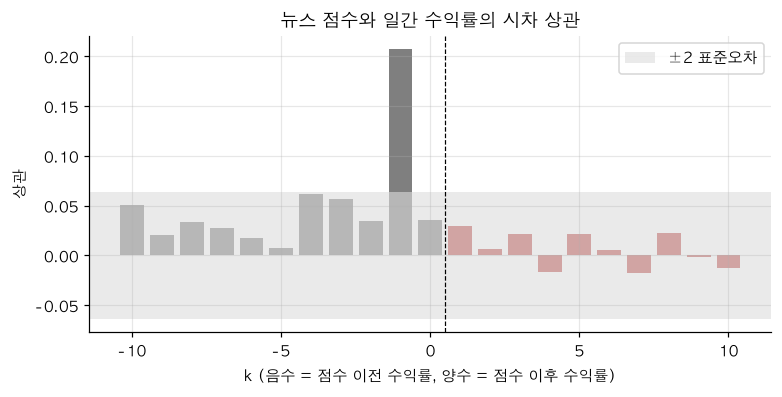

,지난 5일 수익률,다음 5일 수익률
뉴스 점수와의 상관,0.177,0.028


In [5]:
daily_return = np.log(data["close"]).diff()
scored = news["news_score"].notna()
lags = range(-10, 11)
lead_lag = pd.Series({k: news.loc[scored, "news_score"].corr(daily_return.shift(-k)[scored]) for k in lags})
band = 2 / np.sqrt(scored.sum())  # 상관이 0일 때의 대략 ±2 표준오차

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(lead_lag.index, lead_lag, color=["#7f7f7f" if k <= 0 else "#c0504d" for k in lead_lag.index])
ax.axhspan(-band, band, color="#dddddd", alpha=0.6, lw=0, label="±2 표준오차")
ax.axvline(0.5, color="black", lw=0.8, ls="--")
ax.set(xlabel="k (음수 = 점수 이전 수익률, 양수 = 점수 이후 수익률)", ylabel="상관", title="뉴스 점수와 일간 수익률의 시차 상관")
ax.legend()
common.save_fig(fig, "news_hindsight.png")
plt.show()

hindsight = pd.DataFrame({
    "지난 5일 수익률": [news.loc[scored, "news_score"].corr(data.loc[scored, "ret_5"])],
    "다음 5일 수익률": [news.loc[scored, "news_score"].corr(data.loc[scored, "y_5"])],
}, index=["뉴스 점수와의 상관"])
hindsight.round(3)

상관이 가장 큰 곳은 k = −1(0.21)이다. research 시점에서 t일 점수의 기사는 대개 t−1일에 발행되므로, 점수는 **기사가 나온 날의 가격 움직임**과 가장 잘 맞는다. 이후 수익률(k > 0)과의 상관은 모두 ±2 표준오차 안에 있다. 지난 5일 수익률과의 상관(0.18)도 다음 5일 수익률과의 상관(0.03)보다 훨씬 크다. Jev 점수는 대체로 이미 일어난 움직임을 설명한다.

## 4. 사전 등록 실험: 5일 수익률에 뉴스 계수 1개 더하기

- 기준: 현재가 유지(Naive, 예측 수익률 0). 03에서 어떤 회귀 모델도 이 기준을 넘지 못했다.
- 비교: `예측 = β × 뉴스 점수`. 기사가 없는 날의 점수는 0이다. β는 2022년부터 전년 말까지의 자료로 최소제곱 추정한다. 목표일이 전년 말을 넘는 행은 학습에서 뺀다.
- 평가: 2023, 2024, 2025년을 한 해씩 예측하고, 세 해를 합쳐 블록 bootstrap(블록 길이 5)으로 ΔRMSE 구간을 구한다.

In [6]:
H = 5
frame = pd.DataFrame({"y": data[f"y_{H}"], "target_date": data[f"target_date_{H}"],
                      "news": news["news_score"].fillna(0.0)}).loc["2022-01-01":].dropna(subset=["y"])

rows, pooled = [], {"y": [], "naive": [], "news": []}
for year in (2023, 2024, 2025):
    fit_end, test_end = pd.Timestamp(f"{year - 1}-12-31"), pd.Timestamp("2025-12-31")  # 평가 목표일은 구간 끝까지
    fit = frame[(frame.index <= fit_end) & (frame["target_date"] <= fit_end)]
    test = frame[(frame.index.year == year) & (frame["target_date"] <= test_end)]
    beta = float((fit["news"] * fit["y"]).sum() / (fit["news"] ** 2).sum())
    pred = beta * test["news"].to_numpy()
    rmse_naive = float(np.sqrt(np.mean(test["y"] ** 2)))
    rmse_news = float(np.sqrt(np.mean((test["y"] - pred) ** 2)))
    rows.append({"연도": year, "학습 행": len(fit), "평가 행": len(test), "β": beta,
                 "RMSE 현재가": rmse_naive, "RMSE 뉴스": rmse_news, "변화율(%)": 100 * (rmse_news / rmse_naive - 1)})
    pooled["y"].append(test["y"].to_numpy())
    pooled["naive"].append(np.zeros(len(test)))
    pooled["news"].append(pred)

pooled = {key: np.concatenate(value) for key, value in pooled.items()}
ci = block_bootstrap_rmse_diff(pooled["y"], pooled["news"], pooled["naive"], block=H)
adopted = bool(ci["high"] < 0 and all(row["RMSE 뉴스"] < row["RMSE 현재가"] for row in rows))
print(f"ΔRMSE(뉴스 − 현재가) = {ci['diff']:+.5f}, 95% 구간 [{ci['low']:+.5f}, {ci['high']:+.5f}] → 채택: {adopted}")
pd.DataFrame(rows).set_index("연도").round(5)

ΔRMSE(뉴스 − 현재가) = +0.00026, 95% 구간 [-0.00008, +0.00062] → 채택: False


,학습 행,평가 행,β,RMSE 현재가,RMSE 뉴스,변화율(%)
연도,,,,,,
2023,246,250,-0.02056,0.04776,0.04741,-0.74147
2024,496,252,-0.02830,0.04872,0.04972,2.05253
2025,748,246,-0.00717,0.05974,0.05988,0.23204


채택 규칙을 통과하지 못했다. 세 해를 합친 ΔRMSE는 +0.0003으로 오히려 나빠졌고, 구간도 0을 포함한다. 2023년만 0.7% 좋아졌고 2024년(+2.1%)과 2025년(+0.2%)은 나빠졌다. β가 모두 음수인 것도 처음 기대(상승 압력 → 가격 상승)와 반대다. 점수는 이미 오른 날 높게 나오고, 그 뒤에 소폭 되돌림이 있었던 것으로 보인다.

In [7]:
common.save_result("news_diagnostic", {
    "articles": len(articles),
    "label_share_by_year": share.round(3).to_dict(orient="index"),
    "lead_lag_corr": lead_lag.round(4).to_dict(),
    "hindsight": hindsight.round(4).iloc[0].to_dict(),
    "ablation": {"horizon": H, "years": [2023, 2024, 2025], "folds": rows, "pooled": ci, "adopted": adopted},
})

## 정리

- 2022–2025년 뉴스 점수는 2026년에 소급 분류한 값이라 그 시점에 알 수 있던 정보가 아니다. 실시간으로 분석된 기사는 4건뿐이다.
- 점수는 미래보다 과거, 특히 기사가 나온 날의 가격 움직임과 관련된다. 미리 정한 실험에서도 5일 수익률 예측을 개선하지 못했다.
- **결정:** 뉴스는 모델 입력으로 쓰지 않는다. 대시보드에는 '참고 정보, 모델 입력 아님'으로 표시한다. 대신 매일 live 시점 점수를 쌓아 두고, 6개월 치쯤 모이면 같은 규칙으로 다시 검증한다.